In [1]:
%matplotlib inline
# %matplotlib widget
%load_ext autoreload
%autoreload 2

import matplotlib
import torch
import logging 
from pathlib import Path
import random
import numpy as np

import method.datasets as ds
import method.preprocess.preprocess as ps
import method.core.pipeline as pipe
import method.models.rnn.rnn as model

from method.metrics import metrics
from logging_tools.config import setup_logging
from method.viz import plot_data, plot_results, plot_data_compare

import data_configs.custom_data_config as config

CONFIGS_PATH = Path("configs")
DATASET_CONFIG = ds.DatasetConfig.from_dict(config.EXECUTE_CONFIG["dataset"])

setup_logging()
logger = logging.getLogger(__name__)



INFO     Preprocessor.transform start

INFO     Pipeline making step 'shifter'

INFO     Pipeline making step 'drop_intervals'

INFO     Pipeline making step 'filter'

INFO     Pipeline making step 'scaler'

INFO     Pipeline making step 'feature_selector'

INFO     Pipeline making step 'splitter'

INFO     Preprocessor.transform end (0.20)s

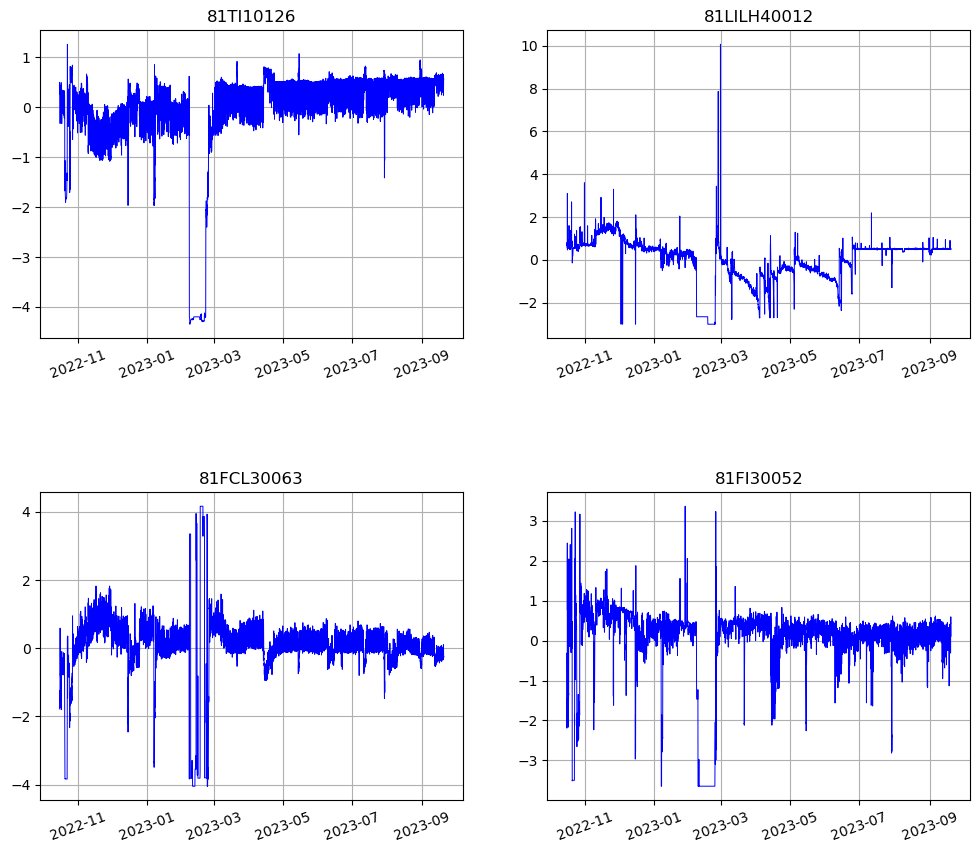

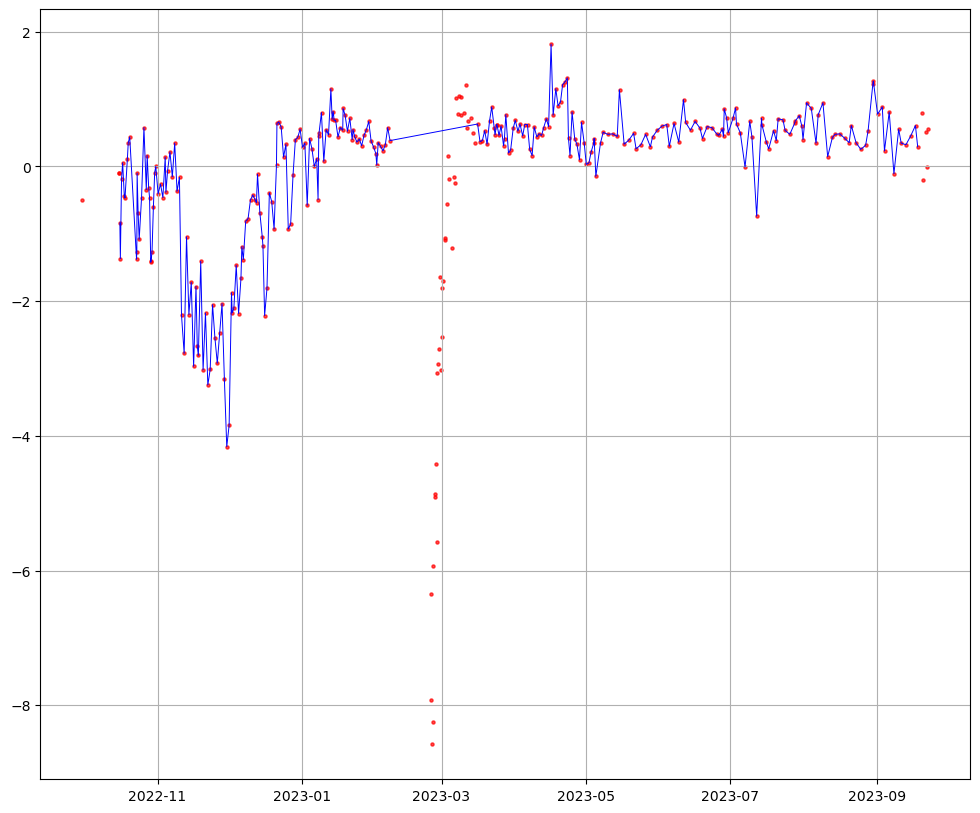

In [2]:
data_raw = ds.LoadDatasetStep(DATASET_CONFIG).fit_transform()


preprocess_config = ps.PreprocessConfig.from_dict(config.EXECUTE_CONFIG["preprocess"])
preprocessor = ps.Preprocessor(preprocess_config)

data = preprocessor.fit_transform(data_raw)

data_merged = data.merge_data()
ds_raw = data_raw.train.replace(new_y_scaler=data.train.y_scaler)
target_raw_scaled = ds_raw.scale(scale_y=True).y
target = data_merged.train.y
plot_data(data_merged.train.X.dropna(), plot_type="plot")
plot_data_compare(target_raw_scaled.dropna(), target.dropna())

INFO     RNN training model

INFO     Computing best lag using spearman correlation...

INFO     epoch 0: train: 0.7799, lr: 1.000e-02, valid: 0.1830, best_valid: 0.1830

INFO     epoch 10: train: 0.2286, lr: 1.000e-02, valid: 0.2800, best_valid: 0.1174

INFO     epoch 20: train: 0.1615, lr: 1.000e-02, valid: 0.3759, best_valid: 0.1174

...

INFO     epoch 60: train: 0.1436, lr: 1.000e-02, valid: 0.0749, best_valid: 0.0693

INFO     epoch 70: train: 0.0991, lr: 1.000e-02, valid: 0.0819, best_valid: 0.0693

INFO     epoch 80: train: 0.1132, lr: 1.000e-02, valid: 0.0804, best_valid: 0.0693

INFO     epoch 90: train: 0.0798, lr: 1.000e-02, valid: 0.0986, best_valid: 0.0693

INFO     RNN Model trained

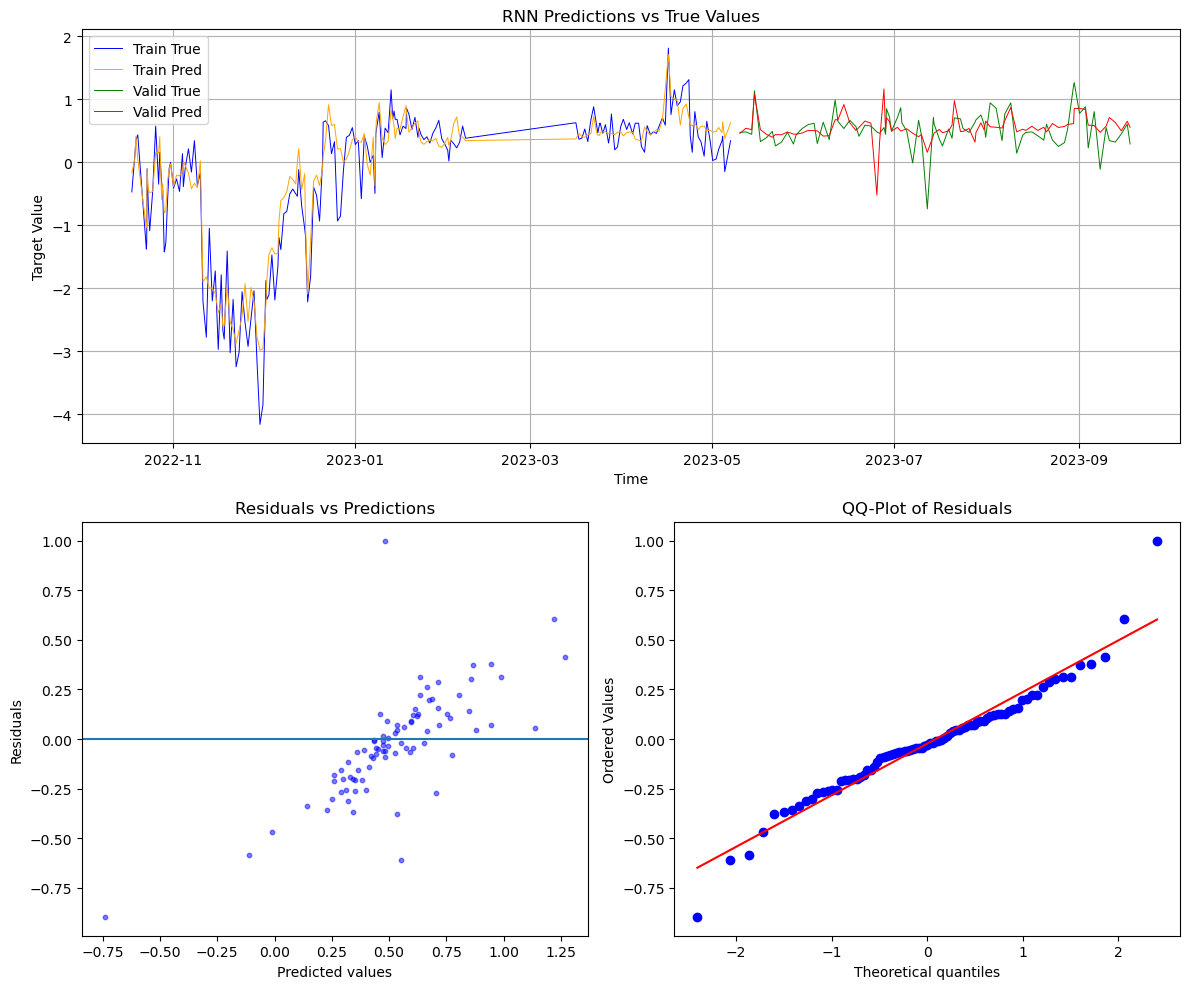

INFO     Metrics for Valid:

INFO                                                                                                               
         MAE                  0.189295                                                                             
         rMSE                 0.263285                                                                             
         MAPE                 0.990236                                                                             
         Pearson (p-value)    0.000081                                                                             
         Pearson              0.414310                                                                             
         R2                   0.079800                                                                             
         Hinge                0.109168                                                                             
         dtype: float64

In [3]:
torch.manual_seed(0)
np.random.seed(42)
random.seed(42)

rnn_config = model.RNNConfig.from_dict(config.EXECUTE_CONFIG["model"])
rnn = model.RNN(rnn_config)

steps = [("rnn", rnn)] 
full_pipeline = pipe.Pipeline(steps)  # type: ignore
result = full_pipeline.fit_transform(data)

plot_results(result)

logger.debug("Metrics for Train:")
logger.debug("\n%s", metrics(**result["train"], cone=0.1))
logger.info("Metrics for Valid:")
logger.info("\n%s", metrics(**result["valid"], cone=0.1))